# Session 1: Data loading and preprocessing

This notebook prepares the hourly electricity demand dataset for forecasting. I load the raw data, inspect its structure, identify the timestamp and target columns, and convert the data into a clean hourly time series with a datetime index.

The preprocessing steps also handle duplicate timestamps and missing values so the series is consistent and ready for modeling in the next notebook. I also include a quick visualization to check the overall shape of the demand pattern and confirm that the cleaned dataset is suitable for time-series forecasting.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/archive/AEP_hourly.csv", parse_dates=["Datetime"])

# Initial inspection
print(df.head())
print(df.info())
print(df.describe())


             Datetime   AEP_MW
0 2004-12-31 01:00:00  13478.0
1 2004-12-31 02:00:00  12865.0
2 2004-12-31 03:00:00  12577.0
3 2004-12-31 04:00:00  12517.0
4 2004-12-31 05:00:00  12670.0
<class 'pandas.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[us]
 1   AEP_MW    121273 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.9 MB
None
                         Datetime         AEP_MW
count                      121273  121273.000000
mean   2011-09-02 03:17:01.553025   15499.513717
min           2004-10-01 01:00:00    9581.000000
25%           2008-03-17 15:00:00   13630.000000
50%           2011-09-02 04:00:00   15310.000000
75%           2015-02-16 17:00:00   17200.000000
max           2018-08-03 00:00:00   25695.000000
std                           NaN    2591.399065


In [2]:
# Identify columns
time_col = "Datetime"
target_col = "AEP_MW"

# Keep only the relevant columns
df = df[[time_col, target_col]].copy()

# Set datetime index and sort
df = df.set_index(time_col).sort_index()

In [3]:
# Check for duplicate timestamps
print("Duplicate timestamps:", df.index.duplicated().sum())

# Enforce hourly frequency
df = df.resample("h").mean()

# Check missing values after resampling
print(df.isna().sum())

Duplicate timestamps: 4
AEP_MW    27
dtype: int64


In [4]:
# Handle missing values 
df[target_col] = df[target_col].interpolate(method="time")

# Final quick checks
print(df.head())
print(df.info())
print(df.describe())

                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0
<class 'pandas.DataFrame'>
DatetimeIndex: 121296 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Freq: h
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121296 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
None
              AEP_MW
count  121296.000000
mean    15499.150331
std      2591.379068
min      9581.000000
25%     13629.000000
50%     15309.000000
75%     17200.000000
max     25695.000000


The dataset is hourly, so resampling to a regular hourly frequency makes the time index consistent before modeling. Time interpolation is appropriate here because the missing values are small gaps in a continuous time series, so it preserves the local temporal pattern without introducing abrupt jumps.

Text(0, 0.5, 'AEP_MW')

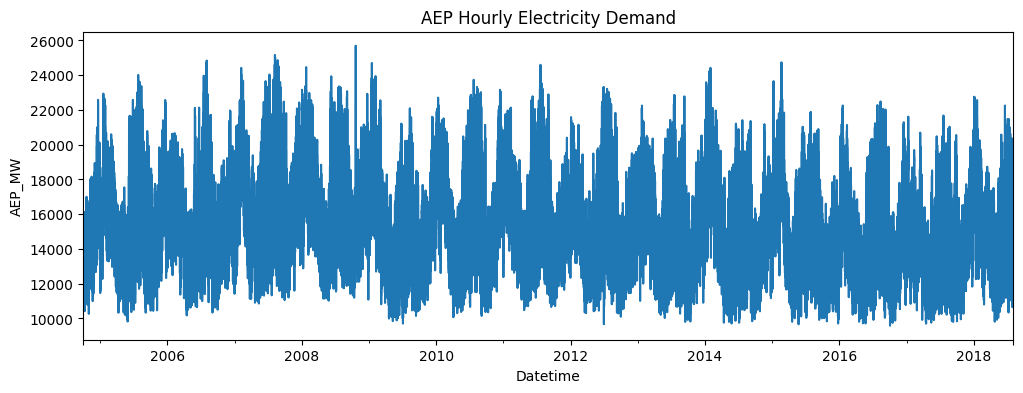

In [5]:
# Visualize the series
ax = df[target_col].plot(figsize=(12, 4), title="AEP Hourly Electricity Demand")
ax.set_xlabel("Datetime")
ax.set_ylabel("AEP_MW")

The series shows long-run level changes and repeated seasonal variation, which motivates the use of time-series forecasting models.

In [6]:
df.to_csv("data/cleaned_aep_hourly.csv")